In [1]:
# ============================================================
# SAOCHECK AI — CELLULE 1
# Installation des bibliothèques
# ============================================================

# Installation des bibliothèques nécessaires au projet.
# Nous utilisons -q ("quiet") afin de limiter les messages
# inutiles pendant l'installation.

!pip install -q -U datasets transformers accelerate scikit-learn openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 90.0 MB/s eta 0:00:00


In [1]:
import pandas as pd
import numpy as np
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

print("Environnement SaoCheck prêt.")

print("\nPyTorch :", torch.__version__)
print("GPU disponible :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

Environnement SaoCheck prêt.

PyTorch : 2.11.0+cu128
GPU disponible : True
GPU : Tesla T4


In [3]:
# ============================================================
# SAOCHECK AI — CELLULE 3
# Chargement de X-FACT — Version française
# ============================================================

from datasets import load_dataset

# ------------------------------------------------------------
# Configuration du dataset
# ------------------------------------------------------------
# X-FACT est disponible dans plusieurs langues.
# Pour le premier modèle SaoCheck, nous sélectionnons
# la configuration française : "fr".

DATASET_NAME = "utahnlp/x-fact"
LANGUAGE_CONFIG = "fr"

print("==============================================")
print("       CHARGEMENT DE X-FACT")
print("==============================================")

print(f"Dataset       : {DATASET_NAME}")
print(f"Configuration : {LANGUAGE_CONFIG}")
print("\nTéléchargement en cours...")

# Chargement de la version française
x_fact = load_dataset(
    DATASET_NAME,
    LANGUAGE_CONFIG
)

print("\n==============================================")
print("       X-FACT CHARGÉ AVEC SUCCÈS")
print("==============================================")

print(x_fact)

       CHARGEMENT DE X-FACT
Dataset       : utahnlp/x-fact
Configuration : fr

Téléchargement en cours...


zeroshot-00000-of-00001.csv:   0%|          | 0.00/363k [00:00<?, ?B/s]

Generating zeroshot split: 0 examples [00:00, ? examples/s]


       X-FACT CHARGÉ AVEC SUCCÈS
DatasetDict({
    zeroshot: Dataset({
        features: ['language', 'site', 'evidence_1', 'evidence_2', 'evidence_3', 'evidence_4', 'evidence_5', 'link_1', 'link_2', 'link_3', 'link_4', 'link_5', 'claimDate', 'reviewDate', 'claimant', 'claim', 'label'],
        num_rows: 198
    })
})


In [4]:
# ============================================================
# SAOCHECK AI — CELLULE 4
# Identification des ensembles X-FACT
# ============================================================

print("==============================================")
print("       ENSEMBLES DISPONIBLES")
print("==============================================")

for i, split_name in enumerate(x_fact.keys(), start=1):
    print(f"{i}. {split_name}")

       ENSEMBLES DISPONIBLES
1. zeroshot


In [5]:
# ============================================================
# SAOCHECK AI — CELLULE 5
# Taille des ensembles X-FACT
# ============================================================

print("==============================================")
print("       TAILLE DES ENSEMBLES")
print("==============================================")

for split_name in x_fact.keys():
    number_of_rows = len(x_fact[split_name])
    print(f"{split_name:<12} : {number_of_rows:,} observations")

       TAILLE DES ENSEMBLES
zeroshot     : 198 observations


In [6]:
# ============================================================
# SAOCHECK AI — CELLULE 6
# Structure des données X-FACT
# ============================================================

print("==============================================")
print("       VARIABLES DISPONIBLES")
print("==============================================")

for split_name in x_fact.keys():

    print(f"\n--- {split_name.upper()} ---")

    for column in x_fact[split_name].column_names:
        print(f"  • {column}")

       VARIABLES DISPONIBLES

--- ZEROSHOT ---
  • language
  • site
  • evidence_1
  • evidence_2
  • evidence_3
  • evidence_4
  • evidence_5
  • link_1
  • link_2
  • link_3
  • link_4
  • link_5
  • claimDate
  • reviewDate
  • claimant
  • claim
  • label


In [7]:
# ============================================================
# SAOCHECK AI — CELLULE 7
# Analyse des labels X-FACT
# ============================================================

print("==============================================")
print("       LABELS DISPONIBLES DANS X-FACT")
print("==============================================")

# Récupération des valeurs du champ label
labels = x_fact["zeroshot"]["label"]

# Conversion en DataFrame pour faciliter l'analyse
label_counts = pd.Series(labels).value_counts()

print("\nNombre total d'observations :", len(labels))

print("\nRépartition des labels :")
print(label_counts)

       LABELS DISPONIBLES DANS X-FACT

Nombre total d'observations : 198

Répartition des labels :
false                             73
complicated/hard to categorise    40
partly true/misleading            36
mostly true                       28
true                              21
Name: count, dtype: int64


In [8]:
# ============================================================
# SAOCHECK AI — CELLULE 8
# Inspection des affirmations et de leurs labels
# ============================================================

# Conversion en DataFrame
x_fact_df = x_fact["zeroshot"].to_pandas()

print("==============================================")
print("       EXEMPLES X-FACT")
print("==============================================")

# Afficher les colonnes essentielles
display(
    x_fact_df[
        ["language", "claim", "label", "site", "claimant"]
    ].head(10)
)

       EXEMPLES X-FACT


,language,claim,label,site,claimant
0,fr,Le Nigeria est le pays qui compte le plus de f...,mostly true,fr.africacheck.org,Malala Yousafzai
1,fr,Le Nigeria ne s'est pas endetté sur le marché ...,false,fr.africacheck.org,Kemi Adeosun
2,fr,Un étranger ne peut pas investir dans les banq...,mostly true,fr.africacheck.org,Bougane Guèye Dany
3,fr,"A part Air Sénégal, aucune compagnie africaine...",false,fr.africacheck.org,"Alioune Sarr, ministre sénégalais du tourisme ..."
4,fr,"En 2015, lors de la première conférence à Abid...",mostly true,fr.africacheck.org,Ousmane Mar Dièye
5,fr,90 % des maires du pays ont un salaire de moin...,partly true/misleading,fr.africacheck.org,Mbaye Dione
6,fr,« 98% des albinos (dans le pays) vivent avec u...,complicated/hard to categorise,fr.africacheck.org,"Mouhamadou Bamba Diop, président de l’Associat..."
7,fr,"Des domestiques africaines ""séquestrées et abu...",complicated/hard to categorise,fr.africacheck.org,Internautes
8,fr,Le Nigeria dépense 7 fois moins en soins de sa...,false,fr.africacheck.org,This Day
9,fr,"« Dans les prévisions, la population sénégalai...",mostly true,fr.africacheck.org,Mamadou Goumbala


In [9]:
# ============================================================
# SAOCHECK AI — CELLULE 9
# Valeurs uniques des labels
# ============================================================

print("==============================================")
print("       VALEURS UNIQUES DES LABELS")
print("==============================================")

unique_labels = sorted(
    x_fact_df["label"]
    .dropna()
    .astype(str)
    .unique()
)

for i, label in enumerate(unique_labels, start=1):
    print(f"{i}. {label}")

       VALEURS UNIQUES DES LABELS
1. complicated/hard to categorise
2. false
3. mostly true
4. partly true/misleading
5. true


In [10]:
# ============================================================
# SAOCHECK AI — CELLULE 10
# DATA INVENTORY — X-FACT
# ============================================================

print("================================================")
print("          X-FACT — DATA INVENTORY")
print("================================================")

# Nombre total d'observations
print("\nNombre total d'observations :", len(x_fact_df))

# Nombre de colonnes
print("Nombre de variables :", len(x_fact_df.columns))

# Liste des variables
print("\nVariables disponibles :")

for i, column in enumerate(x_fact_df.columns, start=1):
    print(f"{i:02d}. {column}")

          X-FACT — DATA INVENTORY

Nombre total d'observations : 198
Nombre de variables : 17

Variables disponibles :
01. language
02. site
03. evidence_1
04. evidence_2
05. evidence_3
06. evidence_4
07. evidence_5
08. link_1
09. link_2
10. link_3
11. link_4
12. link_5
13. claimDate
14. reviewDate
15. claimant
16. claim
17. label


In [11]:
# ============================================================
# SAOCHECK AI — CELLULE 11
# ANALYSE DES DONNÉES MANQUANTES
# ============================================================

print("================================================")
print("       DONNÉES MANQUANTES — X-FACT")
print("================================================")

# Calcul du nombre de valeurs manquantes
missing_count = x_fact_df.isnull().sum()

# Calcul du pourcentage
missing_percent = (
    missing_count / len(x_fact_df) * 100
).round(2)

# Création d'un tableau récapitulatif
missing_table = pd.DataFrame({
    "Variable": missing_count.index,
    "Valeurs_manquantes": missing_count.values,
    "Pourcentage": missing_percent.values
})

# Trier du plus grand au plus petit
missing_table = missing_table.sort_values(
    "Valeurs_manquantes",
    ascending=False
)

display(missing_table)

       DONNÉES MANQUANTES — X-FACT


,Variable,Valeurs_manquantes,Pourcentage
2,evidence_1,42,21.21
3,evidence_2,42,21.21
0,language,0,0.00
1,site,0,0.00
4,evidence_3,0,0.00
5,evidence_4,0,0.00
6,evidence_5,0,0.00
7,link_1,0,0.00
8,link_2,0,0.00
9,link_3,0,0.00


In [12]:
# ============================================================
# SAOCHECK AI — CELLULE 12
# ANALYSE DE LA DISPONIBILITÉ DES PREUVES
# ============================================================

print("================================================")
print("          ANALYSE DES PREUVES")
print("================================================")

evidence_columns = [
    "evidence_1",
    "evidence_2",
    "evidence_3",
    "evidence_4",
    "evidence_5"
]

# Vérifier quelles colonnes existent réellement
evidence_columns = [
    col for col in evidence_columns
    if col in x_fact_df.columns
]

# Nombre de preuves disponibles par observation
x_fact_df["evidence_count"] = (
    x_fact_df[evidence_columns]
    .notna()
    .sum(axis=1)
)

print("\nNombre d'observations avec :")

print(
    "Aucune preuve :",
    (x_fact_df["evidence_count"] == 0).sum()
)

print(
    "Au moins 1 preuve :",
    (x_fact_df["evidence_count"] >= 1).sum()
)

print(
    "Au moins 2 preuves :",
    (x_fact_df["evidence_count"] >= 2).sum()
)

print(
    "Au moins 3 preuves :",
    (x_fact_df["evidence_count"] >= 3).sum()
)

print(
    "Au moins 4 preuves :",
    (x_fact_df["evidence_count"] >= 4).sum()
)

print(
    "5 preuves :",
    (x_fact_df["evidence_count"] == 5).sum()
)

          ANALYSE DES PREUVES

Nombre d'observations avec :
Aucune preuve : 0
Au moins 1 preuve : 198
Au moins 2 preuves : 198
Au moins 3 preuves : 198
Au moins 4 preuves : 156
5 preuves : 156


In [13]:
# ============================================================
# SAOCHECK AI — CELLULE 13
# DATA QUALITY PROFILE — X-FACT
# ============================================================

print("================================================")
print("       X-FACT — DATA QUALITY PROFILE")
print("================================================")

# Nombre total d'observations
n_rows = len(x_fact_df)

# Création du profil de qualité
quality_profile = pd.DataFrame({
    "Variable": x_fact_df.columns,
    "Type": x_fact_df.dtypes.astype(str).values,
    "Valeurs_manquantes": x_fact_df.isna().sum().values,
    "Valeurs_uniques": [
        x_fact_df[col].nunique(dropna=True)
        for col in x_fact_df.columns
    ]
})

# Pourcentage de complétude
quality_profile["Complétude_%"] = (
    100 -
    (quality_profile["Valeurs_manquantes"] / n_rows * 100)
).round(2)

# Trier par complétude
quality_profile = quality_profile.sort_values(
    "Complétude_%",
    ascending=True
)

display(quality_profile)

       X-FACT — DATA QUALITY PROFILE


,Variable,Type,Valeurs_manquantes,Valeurs_uniques,Complétude_%
3,evidence_2,object,42,156,78.79
2,evidence_1,object,42,156,78.79
1,site,object,0,1,100.00
0,language,object,0,1,100.00
4,evidence_3,object,0,198,100.00
5,evidence_4,object,0,198,100.00
6,evidence_5,object,0,198,100.00
7,link_1,object,0,198,100.00
8,link_2,object,0,196,100.00
9,link_3,object,0,193,100.00


In [14]:
# ============================================================
# SAOCHECK AI — CELLULE 14
# ANALYSE DE LA LANGUE
# ============================================================

print("================================================")
print("             LANGUES — X-FACT")
print("================================================")

language_counts = x_fact_df["language"].value_counts(dropna=False)

print(language_counts)

             LANGUES — X-FACT
language
fr    198
Name: count, dtype: int64


In [15]:
# ============================================================
# SAOCHECK AI — CELLULE 15
# ANALYSE DES SOURCES
# ============================================================

print("================================================")
print("             SOURCES — X-FACT")
print("================================================")

print(
    "Nombre de sites différents :",
    x_fact_df["site"].nunique()
)

print("\nTop 20 des sites :")

display(
    x_fact_df["site"]
    .value_counts()
    .head(20)
)

             SOURCES — X-FACT
Nombre de sites différents : 1

Top 20 des sites :


,count
site,
fr.africacheck.org,198


In [16]:
# ============================================================
# SAOCHECK AI — CELLULE 16
# LABELS × SOURCES
# ============================================================

label_site_table = pd.crosstab(
    x_fact_df["site"],
    x_fact_df["label"]
)

print("================================================")
print("           LABELS PAR SOURCE")
print("================================================")

display(
    label_site_table.sort_values(
        by=list(label_site_table.columns),
        ascending=False
    ).head(20)
)

           LABELS PAR SOURCE


label,complicated/hard to categorise,false,mostly true,partly true/misleading,true
site,,,,,
fr.africacheck.org,40,73,28,36,21


In [17]:
# ============================================================
# SAOCHECK AI — CELLULE 17
# APERÇU DES CLAIMS X-FACT
# ============================================================

print("================================================")
print("           APERÇU DES CLAIMS")
print("================================================")

# Sélectionner les variables essentielles
claims_preview = x_fact_df[
    [
        "claim",
        "label",
        "claimant",
        "claimDate",
        "reviewDate"
    ]
].head(10)

# Affichage sous forme de tableau
display(claims_preview)

           APERÇU DES CLAIMS


,claim,label,claimant,claimDate,reviewDate
0,Le Nigeria est le pays qui compte le plus de f...,mostly true,Malala Yousafzai,2017-07-17T00:00:00Z,2017-08-11T09:18:30Z
1,Le Nigeria ne s'est pas endetté sur le marché ...,false,Kemi Adeosun,2017-04-04T00:00:00Z,2017-05-21T18:39:18Z
2,Un étranger ne peut pas investir dans les banq...,mostly true,Bougane Guèye Dany,2018-10-03T00:00:00Z,2019-02-05T03:10:24Z
3,"A part Air Sénégal, aucune compagnie africaine...",false,"Alioune Sarr, ministre sénégalais du tourisme ...",2019-10-14T00:00:00Z,2019-11-28T09:54:59Z
4,"En 2015, lors de la première conférence à Abid...",mostly true,Ousmane Mar Dièye,2017-06-13T00:00:00Z,2017-08-09T08:18:58Z
5,90 % des maires du pays ont un salaire de moin...,partly true/misleading,Mbaye Dione,2019-05-28T00:00:00Z,2019-06-14T18:09:54Z
6,« 98% des albinos (dans le pays) vivent avec u...,complicated/hard to categorise,"Mouhamadou Bamba Diop, président de l’Associat...",2020-06-16T00:00:00Z,2020-07-15T10:12:36Z
7,"Des domestiques africaines ""séquestrées et abu...",complicated/hard to categorise,Internautes,2019-04-02T00:00:00Z,2019-04-17T18:45:56Z
8,Le Nigeria dépense 7 fois moins en soins de sa...,false,This Day,2018-02-15T00:00:00Z,2018-04-05T12:34:57Z
9,"« Dans les prévisions, la population sénégalai...",mostly true,Mamadou Goumbala,2020-06-29T00:00:00Z,2020-08-05T10:05:01Z


In [18]:
# ============================================================
# SAOCHECK AI — CELLULE 18
# APERÇU DES ÉLÉMENTS DE PREUVE
# ============================================================

print("================================================")
print("           APERÇU DES PREUVES")
print("================================================")

# Afficher quelques claims avec leurs preuves
evidence_preview = x_fact_df[
    [
        "claim",
        "evidence_1",
        "evidence_2",
        "evidence_3",
        "evidence_4",
        "evidence_5",
        "label"
    ]
].head(5)

display(evidence_preview)

           APERÇU DES PREUVES


,claim,evidence_1,evidence_2,evidence_3,evidence_4,evidence_5,label
0,Le Nigeria est le pays qui compte le plus de f...,None,None,Le Nigeria est le pays qui compte le plus de f...,C'est là déjà un choix: donner la voix au mond...,L'histoire de la petite fille du Malawi n'est ...,mostly true
1,Le Nigeria ne s'est pas endetté sur le marché ...,"May 21, 2017 — Pour le financement de celles-c...","Jan 16, 2020 — Ceci étant dit, le taux d'endet...","Le Nigéria est en difficulté et même le Kenya,...","Jun 18, 2018 — économique désastreux et l'écon...",engagements extérieurs du secteur public depui...,false
2,Un étranger ne peut pas investir dans les banq...,Un étranger ne peut pas investir dans les banq...,Connaître le contexte de l'investissement étra...,Le secteur financier éthiopien est contrôlé pa...,"2017/06/16 — L'Ethiopie, la plus dynamique éco...",2019/06/21 — L 'Ethiopie a le deuxième plus gr...,mostly true
3,"A part Air Sénégal, aucune compagnie africaine...",None,None,"A part Air SÃ©nÃ©gal, aucune compagnie africai...",2019/03/11 â€” La compagnie aÃ©rienne Air SÃ©n...,2019/01/29 â€” Airbus a obtenu pour son A330-9...,false
4,"En 2015, lors de la première conférence à Abid...",None,None,"En 2015, lors de la première conférence à Abid...","dure depuis quinze ans déjà, elle ne pourra se...","M. Dieye : En 2015, lors de la première confér...",mostly true


In [19]:
# ============================================================
# SAOCHECK AI — CELLULE 19
# ANALYSE DE LA LONGUEUR DES CLAIMS
# ============================================================

print("================================================")
print("       LONGUEUR DES CLAIMS")
print("================================================")

# Nombre de caractères par claim
x_fact_df["claim_length_chars"] = (
    x_fact_df["claim"]
    .astype(str)
    .str.len()
)

# Nombre approximatif de mots
x_fact_df["claim_length_words"] = (
    x_fact_df["claim"]
    .astype(str)
    .str.split()
    .str.len()
)

# Statistiques descriptives
print("\nLongueur en caractères :")
print(
    x_fact_df["claim_length_chars"].describe()
)

print("\nLongueur en mots :")
print(
    x_fact_df["claim_length_words"].describe()
)

       LONGUEUR DES CLAIMS

Longueur en caractères :
count    198.000000
mean      96.707071
std       44.295329
min       28.000000
25%       66.000000
50%       89.000000
75%      122.000000
max      272.000000
Name: claim_length_chars, dtype: float64

Longueur en mots :
count    198.000000
mean      16.797980
std        7.491423
min        5.000000
25%       12.000000
50%       15.000000
75%       21.000000
max       44.000000
Name: claim_length_words, dtype: float64


          DISTRIBUTION DES LABELS
label
false                             73
complicated/hard to categorise    40
partly true/misleading            36
mostly true                       28
true                              21
Name: count, dtype: int64


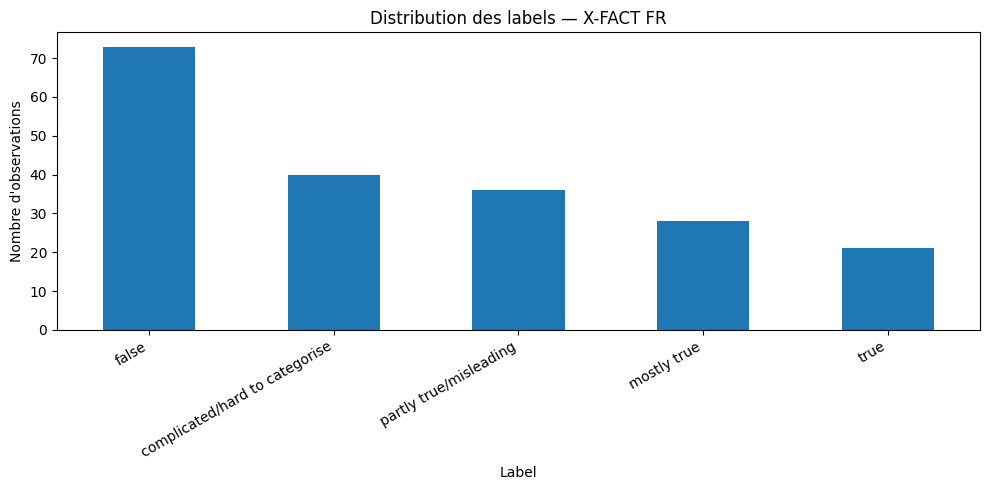

In [20]:
# ============================================================
# SAOCHECK AI — CELLULE 20
# DISTRIBUTION DES LABELS
# ============================================================

import matplotlib.pyplot as plt

print("================================================")
print("          DISTRIBUTION DES LABELS")
print("================================================")

label_distribution = (
    x_fact_df["label"]
    .value_counts()
)

print(label_distribution)

# Graphique
label_distribution.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Distribution des labels — X-FACT FR")
plt.xlabel("Label")
plt.ylabel("Nombre d'observations")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# SAOCHECK AI — CELLULE 21
# CRÉATION DU DATASET DE CLASSIFICATION
# ============================================================

print("================================================")
print("       PRÉPARATION DU DATASET X-FACT")
print("================================================")

# ------------------------------------------------------------
# Sélection des variables nécessaires au premier modèle
# ------------------------------------------------------------
# Pour le MVP-1, nous utilisons uniquement le claim.
# Les éléments de preuve seront conservés pour une future
# version du système.

classification_df = x_fact_df[
    ["claim", "label"]
].copy()

# ------------------------------------------------------------
# Suppression des éventuelles lignes incomplètes
# ------------------------------------------------------------

classification_df = classification_df.dropna(
    subset=["claim", "label"]
)

# ------------------------------------------------------------
# Suppression des claims vides
# ------------------------------------------------------------

classification_df["claim"] = (
    classification_df["claim"]
    .astype(str)
    .str.strip()
)

classification_df = classification_df[
    classification_df["claim"] != ""
].copy()

# ------------------------------------------------------------
# Réinitialisation de l'index
# ------------------------------------------------------------

classification_df = classification_df.reset_index(
    drop=True
)

print("Nombre final d'observations :",
      len(classification_df))

print("\nVariables utilisées :")
print(classification_df.columns.tolist())

print("\nAperçu :")
display(classification_df.head())

       PRÉPARATION DU DATASET X-FACT
Nombre final d'observations : 198

Variables utilisées :
['claim', 'label']

Aperçu :


,claim,label
0,Le Nigeria est le pays qui compte le plus de f...,mostly true
1,Le Nigeria ne s'est pas endetté sur le marché ...,false
2,Un étranger ne peut pas investir dans les banq...,mostly true
3,"A part Air Sénégal, aucune compagnie africaine...",false
4,"En 2015, lors de la première conférence à Abid...",mostly true


In [22]:
# ============================================================
# SAOCHECK AI — CELLULE 22
# VÉRIFICATION DES CLASSES
# ============================================================

print("================================================")
print("          CLASSES X-FACT")
print("================================================")

label_counts = (
    classification_df["label"]
    .value_counts()
)

display(label_counts)

          CLASSES X-FACT


,count
label,
false,73
complicated/hard to categorise,40
partly true/misleading,36
mostly true,28
true,21


In [23]:
# ============================================================
# SAOCHECK AI — CELLULE 23
# ENCODAGE DES LABELS
# ============================================================

print("================================================")
print("          ENCODAGE DES LABELS")
print("================================================")

# Liste des classes X-FACT
label_names = [
    "false",
    "complicated/hard to categorise",
    "partly true/misleading",
    "mostly true",
    "true"
]

# Mapping texte → nombre
label2id = {
    label: index
    for index, label in enumerate(label_names)
}

# Mapping nombre → texte
id2label = {
    index: label
    for index, label in enumerate(label_names)
}

print("Correspondance des labels :\n")

for label, index in label2id.items():
    print(f"{label:<35} → {index}")

# Création de la colonne numérique
classification_df["label_id"] = (
    classification_df["label"]
    .map(label2id)
)

print("\nAperçu :")

display(
    classification_df[
        ["claim", "label", "label_id"]
    ].head(10)
)

          ENCODAGE DES LABELS
Correspondance des labels :

false                               → 0
complicated/hard to categorise      → 1
partly true/misleading              → 2
mostly true                         → 3
true                                → 4

Aperçu :


,claim,label,label_id
0,Le Nigeria est le pays qui compte le plus de f...,mostly true,3
1,Le Nigeria ne s'est pas endetté sur le marché ...,false,0
2,Un étranger ne peut pas investir dans les banq...,mostly true,3
3,"A part Air Sénégal, aucune compagnie africaine...",false,0
4,"En 2015, lors de la première conférence à Abid...",mostly true,3
5,90 % des maires du pays ont un salaire de moin...,partly true/misleading,2
6,« 98% des albinos (dans le pays) vivent avec u...,complicated/hard to categorise,1
7,"Des domestiques africaines ""séquestrées et abu...",complicated/hard to categorise,1
8,Le Nigeria dépense 7 fois moins en soins de sa...,false,0
9,"« Dans les prévisions, la population sénégalai...",mostly true,3


In [24]:
# ============================================================
# SAOCHECK AI — CELLULE 24
# CONTRÔLE DE L'ENCODAGE
# ============================================================

print("================================================")
print("       CONTRÔLE DE L'ENCODAGE")
print("================================================")

# Vérifier qu'aucun label n'a été mal converti
unknown_labels = classification_df[
    classification_df["label_id"].isna()
]

print(
    "Labels non reconnus :",
    len(unknown_labels)
)

# Vérifier la distribution numérique
print("\nDistribution des classes :")

display(
    classification_df["label_id"]
    .value_counts()
    .sort_index()
)

# Vérification finale
if len(unknown_labels) == 0:
    print("\n✅ Encodage effectué correctement.")
else:
    print("\n⚠️ Certains labels n'ont pas été reconnus.")

       CONTRÔLE DE L'ENCODAGE
Labels non reconnus : 0

Distribution des classes :


,count
label_id,
0,73
1,40
2,36
3,28
4,21



✅ Encodage effectué correctement.


In [25]:
# ============================================================
# SAOCHECK AI — CELLULE 25
# SÉPARATION TRAIN / VALIDATION / TEST
# ============================================================

from sklearn.model_selection import train_test_split

print("================================================")
print("     SÉPARATION DES DONNÉES X-FACT")
print("================================================")

# ------------------------------------------------------------
# Données d'entrée
# ------------------------------------------------------------

X = classification_df["claim"]

y = classification_df["label_id"]

# ------------------------------------------------------------
# 1. Séparation TRAIN / TEMPORAIRE
# ------------------------------------------------------------
# 70 % pour l'entraînement
# 30 % pour validation + test

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# ------------------------------------------------------------
# 2. Séparation VALIDATION / TEST
# ------------------------------------------------------------
# Les 30 % restants sont divisés en deux parties égales :
# environ 15 % validation et 15 % test.

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

# ------------------------------------------------------------
# Affichage des tailles
# ------------------------------------------------------------

print("\nNombre de données :")
print("--------------------")
print(f"Train       : {len(X_train)}")
print(f"Validation  : {len(X_val)}")
print(f"Test        : {len(X_test)}")
print(f"Total       : {len(X_train) + len(X_val) + len(X_test)}")

     SÉPARATION DES DONNÉES X-FACT

Nombre de données :
--------------------
Train       : 138
Validation  : 30
Test        : 30
Total       : 198


In [26]:
# ============================================================
# SAOCHECK AI — CELLULE 26
# VÉRIFICATION DE LA STRATIFICATION
# ============================================================

print("================================================")
print("       RÉPARTITION DES CLASSES")
print("================================================")

# Fonction permettant d'afficher la distribution
def display_class_distribution(name, labels):

    print(f"\n--- {name.upper()} ---")

    distribution = pd.Series(labels).value_counts().sort_index()

    for label_id, count in distribution.items():
        label_name = id2label[int(label_id)]
        print(
            f"{label_id} | "
            f"{label_name:<35} | "
            f"{count}"
        )


# Distribution TRAIN
display_class_distribution(
    "Train",
    y_train
)

# Distribution VALIDATION
display_class_distribution(
    "Validation",
    y_val
)

# Distribution TEST
display_class_distribution(
    "Test",
    y_test
)

       RÉPARTITION DES CLASSES

--- TRAIN ---
0 | false                               | 51
1 | complicated/hard to categorise      | 28
2 | partly true/misleading              | 25
3 | mostly true                         | 19
4 | true                                | 15

--- VALIDATION ---
0 | false                               | 11
1 | complicated/hard to categorise      | 6
2 | partly true/misleading              | 5
3 | mostly true                         | 5
4 | true                                | 3

--- TEST ---
0 | false                               | 11
1 | complicated/hard to categorise      | 6
2 | partly true/misleading              | 6
3 | mostly true                         | 4
4 | true                                | 3


In [27]:
# ============================================================
# SAOCHECK AI — CELLULE 27
# CRÉATION DES DATAFRAMES FINAUX
# ============================================================

print("================================================")
print("       DATASETS FINAUX POUR LE MODÈLE")
print("================================================")

# ------------------------------------------------------------
# Dataset TRAIN
# ------------------------------------------------------------

train_df = pd.DataFrame({
    "text": X_train.values,
    "label": y_train.values
})

# ------------------------------------------------------------
# Dataset VALIDATION
# ------------------------------------------------------------

validation_df = pd.DataFrame({
    "text": X_val.values,
    "label": y_val.values
})

# ------------------------------------------------------------
# Dataset TEST
# ------------------------------------------------------------

test_df = pd.DataFrame({
    "text": X_test.values,
    "label": y_test.values
})

# ------------------------------------------------------------
# Réinitialisation des index
# ------------------------------------------------------------

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# ------------------------------------------------------------
# Résumé
# ------------------------------------------------------------

print("\nTRAIN :", train_df.shape)
print("VALIDATION :", validation_df.shape)
print("TEST :", test_df.shape)

print("\nAperçu TRAIN :")
display(train_df.head())

       DATASETS FINAUX POUR LE MODÈLE

TRAIN : (138, 2)
VALIDATION : (30, 2)
TEST : (30, 2)

Aperçu TRAIN :


,text,label
0,"Entrée en vigueur au Sénégal, en janvier 2016,...",0
1,Le Sénégal a enregistré des taux de croissance...,0
2,Seuls 20 % des Africains ont accès à l'électri...,0
3,Placer de l'oignon sous sa chaussette pendant ...,1
4,Le Train Express Régional (TER) de Dakar a coû...,0


In [3]:
# ============================================================
# SAOCHECK AI — CELLULE 27 BIS
# RECONSTRUCTION DES DATAFRAMES
# ============================================================

print("================================================")
print("   RECONSTRUCTION DES DATAFRAMES SAOCHECK")
print("================================================")

# Vérifier que les variables nécessaires existent
variables_requises = [
    "X_train", "X_val", "X_test",
    "y_train", "y_val", "y_test"
]

variables_manquantes = [
    var for var in variables_requises
    if var not in globals()
]

if variables_manquantes:

    print("Variables manquantes :", variables_manquantes)
    print()
    print("Veuillez réexécuter la cellule 25.")

else:

    # Création du DataFrame TRAIN
    train_df = pd.DataFrame({
        "text": X_train.values,
        "label": y_train.values
    })

    # Création du DataFrame VALIDATION
    validation_df = pd.DataFrame({
        "text": X_val.values,
        "label": y_val.values
    })

    # Création du DataFrame TEST
    test_df = pd.DataFrame({
        "text": X_test.values,
        "label": y_test.values
    })

    # Réinitialisation des index
    train_df = train_df.reset_index(drop=True)
    validation_df = validation_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

    print()
    print("DataFrames recréés avec succès.")
    print()
    print("Dimensions :")
    print("--------------------")
    print("TRAIN       :", train_df.shape)
    print("VALIDATION  :", validation_df.shape)
    print("TEST        :", test_df.shape)

   RECONSTRUCTION DES DATAFRAMES SAOCHECK
Variables manquantes : ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test']

Veuillez réexécuter la cellule 25.


In [6]:
# ============================================================
# SAOCHECK AI — CELLULE DE RÉCUPÉRATION COMPLÈTE
# X-FACT → NETTOYAGE → LABELS → TRAIN/VAL/TEST → DATASET
# ============================================================

import pandas as pd
from datasets import load_dataset, Dataset, DatasetDict
from sklearn.model_selection import train_test_split

print("================================================")
print("       RECHARGEMENT COMPLET DE X-FACT")
print("================================================")

# ------------------------------------------------------------
# 1. CHARGEMENT DE X-FACT
# ------------------------------------------------------------

print("\n[1/7] Chargement de X-FACT...")

x_fact = load_dataset(
    "utahnlp/x-fact",
    "fr"
)

print("Configuration française chargée.")

# ------------------------------------------------------------
# 2. RÉCUPÉRATION DE L'ENSEMBLE ZEROSHOT
# ------------------------------------------------------------

print("\n[2/7] Récupération des données...")

print("Ensembles disponibles :", list(x_fact.keys()))

# X-FACT utilise ici l'ensemble zeroshot
x_fact_df = x_fact["zeroshot"].to_pandas()

print("Nombre d'observations :", len(x_fact_df))
print("Nombre de variables :", len(x_fact_df.columns))

# ------------------------------------------------------------
# 3. CRÉATION DU DATASET DE CLASSIFICATION
# ------------------------------------------------------------

print("\n[3/7] Préparation des claims...")

classification_df = x_fact_df[
    ["claim", "label"]
].copy()

# Supprimer les valeurs manquantes
classification_df = classification_df.dropna(
    subset=["claim", "label"]
)

# Nettoyer les textes
classification_df["claim"] = (
    classification_df["claim"]
    .astype(str)
    .str.strip()
)

# Supprimer les claims vides
classification_df = classification_df[
    classification_df["claim"] != ""
].copy()

classification_df = classification_df.reset_index(
    drop=True
)

print(
    "Observations après nettoyage :",
    len(classification_df)
)

# ------------------------------------------------------------
# 4. ENCODAGE DES LABELS
# ------------------------------------------------------------

print("\n[4/7] Encodage des labels...")

label_names = [
    "false",
    "complicated/hard to categorise",
    "partly true/misleading",
    "mostly true",
    "true"
]

label2id = {
    label: index
    for index, label in enumerate(label_names)
}

id2label = {
    index: label
    for index, label in enumerate(label_names)
}

classification_df["label_id"] = (
    classification_df["label"]
    .map(label2id)
)

# Vérification
if classification_df["label_id"].isna().any():

    print("❌ ERREUR : certains labels ne sont pas reconnus.")

    print(
        classification_df[
            classification_df["label_id"].isna()
        ]["label"].unique()
    )

else:

    print("✅ Tous les labels sont correctement encodés.")

    print("\nCorrespondance :")

    for label_id, label_name in id2label.items():
        print(
            f"{label_id} → {label_name}"
        )

# ------------------------------------------------------------
# 5. SÉPARATION TRAIN / VALIDATION / TEST
# ------------------------------------------------------------

print("\n[5/7] Séparation des données...")

X = classification_df["claim"]
y = classification_df["label_id"]

# TRAIN = 70 %
# TEMP = 30 %

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# VALIDATION = 15 %
# TEST = 15 %

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train       :", len(X_train))
print("Validation  :", len(X_val))
print("Test        :", len(X_test))
print(
    "Total       :",
    len(X_train) + len(X_val) + len(X_test)
)

# ------------------------------------------------------------
# 6. CRÉATION DES DATAFRAMES
# ------------------------------------------------------------

print("\n[6/7] Création des DataFrames...")

train_df = pd.DataFrame({
    "text": X_train.values,
    "label": y_train.values
})

validation_df = pd.DataFrame({
    "text": X_val.values,
    "label": y_val.values
})

test_df = pd.DataFrame({
    "text": X_test.values,
    "label": y_test.values
})

# ------------------------------------------------------------
# 7. CRÉATION DU DATASETDICT HUGGING FACE
# ------------------------------------------------------------

print("\n[7/7] Création du DatasetDict...")

dataset = DatasetDict({

    "train": Dataset.from_pandas(
        train_df,
        preserve_index=False
    ),

    "validation": Dataset.from_pandas(
        validation_df,
        preserve_index=False
    ),

    "test": Dataset.from_pandas(
        test_df,
        preserve_index=False
    )
})

# ============================================================
# RÉSUMÉ FINAL
# ============================================================

print("\n")
print("================================================")
print("       PIPELINE X-FACT RESTAURÉ")
print("================================================")

print(dataset)

print("\nVariables disponibles :")
print("----------------------")
print("x_fact")
print("x_fact_df")
print("classification_df")
print("train_df")
print("validation_df")
print("test_df")
print("dataset")
print("label2id")
print("id2label")

print("\n✅ PIPELINE PRÊT POUR LA TOKENISATION.")

       RECHARGEMENT COMPLET DE X-FACT

[1/7] Chargement de X-FACT...


README.md:   0%|          | 0.00/5.76k [00:00<?, ?B/s]

zeroshot-00000-of-00001.csv:   0%|          | 0.00/363k [00:00<?, ?B/s]

Generating zeroshot split: 0 examples [00:00, ? examples/s]

Configuration française chargée.

[2/7] Récupération des données...
Ensembles disponibles : ['zeroshot']
Nombre d'observations : 198
Nombre de variables : 17

[3/7] Préparation des claims...
Observations après nettoyage : 198

[4/7] Encodage des labels...
✅ Tous les labels sont correctement encodés.

Correspondance :
0 → false
1 → complicated/hard to categorise
2 → partly true/misleading
3 → mostly true
4 → true

[5/7] Séparation des données...
Train       : 138
Validation  : 30
Test        : 30
Total       : 198

[6/7] Création des DataFrames...

[7/7] Création du DatasetDict...


       PIPELINE X-FACT RESTAURÉ
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 138
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 30
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 30
    })
})

Variables disponibles :
----------------------
x_fact
x_fact_df
classification_df
train_df
validat

In [7]:
# ============================================================
# SAOCHECK AI — CELLULE 31
# CHARGEMENT DU TOKENIZER CAMEMBERT
# ============================================================

from transformers import AutoTokenizer

print("================================================")
print("       CHARGEMENT DU TOKENIZER")
print("================================================")

# ------------------------------------------------------------
# Modèle français utilisé pour le MVP
# ------------------------------------------------------------

MODEL_NAME = "camembert-base"

# ------------------------------------------------------------
# Chargement du tokenizer
# ------------------------------------------------------------

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print()
print("Tokenizer chargé avec succès.")
print("Modèle :", MODEL_NAME)

       CHARGEMENT DU TOKENIZER


config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.40M [00:00<?, ?B/s]


Tokenizer chargé avec succès.
Modèle : camembert-base


In [8]:
# ============================================================
# SAOCHECK AI — CELLULE 32
# TEST DU TOKENIZER
# ============================================================

print("================================================")
print("          TEST DU TOKENIZER")
print("================================================")

# Récupérer un exemple du dataset TRAIN
example_text = dataset["train"][0]["text"]

print("\nTexte original :")
print(example_text)

# Tokenisation
encoded_example = tokenizer(
    example_text,
    truncation=True,
    max_length=128
)

print("\nTokens encodés :")
print(encoded_example)

print("\nNombre de tokens :")
print(len(encoded_example["input_ids"]))

          TEST DU TOKENIZER

Texte original :
Entrée en vigueur au Sénégal, en janvier 2016, d'une loi relative à l''importation et à la production de sachets plastiques.

Tokens encodés :
{'input_ids': [5, 11661, 22, 2979, 36, 6933, 7, 22, 695, 3590, 18, 11, 70, 589, 3443, 15, 17, 11, 11, 16930, 14, 15, 13, 844, 8, 12059, 10, 11090, 9, 6], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

Nombre de tokens :
30


In [9]:
# ============================================================
# SAOCHECK AI — CELLULE 33
# TOKENISATION DU DATASET X-FACT
# ============================================================

print("================================================")
print("          TOKENISATION DE X-FACT")
print("================================================")

# ------------------------------------------------------------
# Fonction de tokenisation
# ------------------------------------------------------------

def tokenize_function(examples):

    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )


# ------------------------------------------------------------
# Application au DatasetDict
# ------------------------------------------------------------

tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True
)

print()
print("✅ Tokenisation terminée.")

print("\nStructure du dataset tokenisé :")
print(tokenized_dataset)

          TOKENISATION DE X-FACT


Map:   0%|          | 0/138 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]


✅ Tokenisation terminée.

Structure du dataset tokenisé :
DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 138
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 30
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 30
    })
})


In [10]:
# ============================================================
# SAOCHECK AI — CELLULE 34
# VÉRIFICATION DES DONNÉES TOKENISÉES
# ============================================================

print("================================================")
print("      VÉRIFICATION DES DONNÉES TOKENISÉES")
print("================================================")

# Afficher la première observation du TRAIN
example = tokenized_dataset["train"][0]

print("\nClés disponibles :")
print(list(example.keys()))

print("\nTexte :")
print(example["text"])

print("\nLabel :")
print(example["label"])

print("\nNombre de tokens :")
print(len(example["input_ids"]))

print("\nNombre de positions d'attention :")
print(len(example["attention_mask"]))

print("\n✅ Vérification terminée.")

      VÉRIFICATION DES DONNÉES TOKENISÉES

Clés disponibles :
['text', 'label', 'input_ids', 'attention_mask']

Texte :
Entrée en vigueur au Sénégal, en janvier 2016, d'une loi relative à l''importation et à la production de sachets plastiques.

Label :
0

Nombre de tokens :
128

Nombre de positions d'attention :
128

✅ Vérification terminée.


In [11]:
# ============================================================
# SAOCHECK AI — CELLULE 35
# CHARGEMENT DE CAMEMBERT POUR 5 CLASSES
# ============================================================

from transformers import AutoModelForSequenceClassification

print("================================================")
print("      CHARGEMENT DE CAMEMBERT")
print("================================================")

MODEL_NAME = "camembert-base"

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=5,
    id2label=id2label,
    label2id=label2id
)

print()
print("✅ Modèle chargé avec succès.")
print("Architecture :", MODEL_NAME)
print("Nombre de classes :", model.config.num_labels)

print("\nClasses :")

for label_id, label_name in id2label.items():
    print(f"{label_id} → {label_name}")

      CHARGEMENT DE CAMEMBERT


model.safetensors: reconstructing file:   0%|          |  0.00B /  445MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✅ Modèle chargé avec succès.
Architecture : camembert-base
Nombre de classes : 5

Classes :
0 → false
1 → complicated/hard to categorise
2 → partly true/misleading
3 → mostly true
4 → true


In [12]:
# ============================================================
# SAOCHECK AI — CELLULE 36
# PRÉPARATION DU DATASET POUR L'ENTRAÎNEMENT
# ============================================================

print("================================================")
print("     PRÉPARATION DU DATASET POUR TRANSFORMERS")
print("================================================")

# Colonnes nécessaires au modèle
columns_to_keep = [
    "input_ids",
    "attention_mask",
    "label"
]

tokenized_dataset = tokenized_dataset.remove_columns(
    [
        column
        for column in tokenized_dataset["train"].column_names
        if column not in columns_to_keep
    ]
)

# Format PyTorch
tokenized_dataset.set_format(
    "torch"
)

print()
print("Colonnes finales :")
print(tokenized_dataset["train"].column_names)

print()
print("Structure finale :")
print(tokenized_dataset)

print()
print("✅ Dataset prêt pour PyTorch / Transformers.")

     PRÉPARATION DU DATASET POUR TRANSFORMERS

Colonnes finales :
['label', 'input_ids', 'attention_mask']

Structure finale :
DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 138
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 30
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 30
    })
})

✅ Dataset prêt pour PyTorch / Transformers.


In [13]:
# ============================================================
# SAOCHECK AI — CELLULE 37
# MÉTRIQUES D'ÉVALUATION
# ============================================================

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

print("================================================")
print("          CONFIGURATION DES MÉTRIQUES")
print("================================================")


def compute_metrics(eval_pred):

    # Récupération des prédictions et des vrais labels
    logits, labels = eval_pred

    # Conversion des logits en classes prédites
    predictions = np.argmax(logits, axis=-1)

    # Accuracy
    accuracy = accuracy_score(
        labels,
        predictions
    )

    # Precision, Recall et F1
    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


print()
print("Métriques configurées :")
print("• Accuracy")
print("• Precision macro")
print("• Recall macro")
print("• F1 macro")

print()
print("✅ Fonction d'évaluation prête.")

          CONFIGURATION DES MÉTRIQUES

Métriques configurées :
• Accuracy
• Precision macro
• Recall macro
• F1 macro

✅ Fonction d'évaluation prête.


In [14]:
# ============================================================
# SAOCHECK AI — CELLULE 38
# CONFIGURATION DU FINE-TUNING
# ============================================================

from transformers import TrainingArguments

print("================================================")
print("       CONFIGURATION DE L'ENTRAÎNEMENT")
print("================================================")

training_args = TrainingArguments(

    # --------------------------------------------------------
    # Dossier de sortie
    # --------------------------------------------------------

    output_dir="./saocheck_camembert_xfact",

    # --------------------------------------------------------
    # Évaluation pendant l'entraînement
    # --------------------------------------------------------

    eval_strategy="epoch",

    # --------------------------------------------------------
    # Sauvegarde du modèle
    # --------------------------------------------------------

    save_strategy="epoch",

    # Garder uniquement les meilleurs checkpoints
    save_total_limit=2,

    # --------------------------------------------------------
    # Hyperparamètres
    # --------------------------------------------------------

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=5,

    weight_decay=0.01,

    # --------------------------------------------------------
    # Sélection du meilleur modèle
    # --------------------------------------------------------

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    # --------------------------------------------------------
    # Journalisation
    # --------------------------------------------------------

    logging_strategy="epoch",

    # --------------------------------------------------------
    # Optimisation
    # --------------------------------------------------------

    fp16=True,

    # --------------------------------------------------------
    # Rapport
    # --------------------------------------------------------

    report_to="none"
)

print()
print("Paramètres principaux :")
print("------------------------")
print("Learning rate :", training_args.learning_rate)
print("Batch size    :", training_args.per_device_train_batch_size)
print("Epochs        :", training_args.num_train_epochs)
print("Weight decay  :", training_args.weight_decay)
print("FP16          :", training_args.fp16)

print()
print("✅ Configuration terminée.")

       CONFIGURATION DE L'ENTRAÎNEMENT

Paramètres principaux :
------------------------
Learning rate : 2e-05
Batch size    : 8
Epochs        : 5
Weight decay  : 0.01
FP16          : True

✅ Configuration terminée.


In [15]:
# ============================================================
# SAOCHECK AI — CELLULE 39
# CRÉATION DU TRAINER
# ============================================================

from transformers import Trainer

print("================================================")
print("            CRÉATION DU TRAINER")
print("================================================")

trainer = Trainer(

    # Modèle CamemBERT
    model=model,

    # Données d'entraînement
    train_dataset=tokenized_dataset["train"],

    # Données de validation
    eval_dataset=tokenized_dataset["validation"],

    # Paramètres d'entraînement
    args=training_args,

    # Fonction de calcul des métriques
    compute_metrics=compute_metrics
)

print()
print("✅ Trainer créé avec succès.")

print()
print("Le système est maintenant prêt pour le")
print("fine-tuning de CamemBERT sur X-FACT.")

            CRÉATION DU TRAINER

✅ Trainer créé avec succès.

Le système est maintenant prêt pour le
fine-tuning de CamemBERT sur X-FACT.


In [17]:
!apt-get -qq install -y libarchive-dev && pip install -U libarchive
import libarchive

Selecting previously unselected package libarchive-dev:amd64.
(Reading database ... 122579 files and directories currently installed.)
Preparing to unpack .../libarchive-dev_3.6.0-1ubuntu1.8_amd64.deb ...
Unpacking libarchive-dev:amd64 (3.6.0-1ubuntu1.8) ...
Setting up libarchive-dev:amd64 (3.6.0-1ubuntu1.8) ...
Processing triggers for man-db (2.10.2-1) ...
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 11.7 MB/s eta 0:00:00
  Created wheel for libarchive: filename=libarchive-0.4.7-py3-none-any.whl size=31629 sha256=95f8ab4a5bc1188706c5f33fa57cb39220dbded1ec70b4d40ab0250425eec3a1
  Stored in directory: /root/.cache/pip/wheels/9f/6a/45/a72e740bd0da1dfcfce8e50fb74747a3b410458415c2badbfb
Successfully built libarchive


In [19]:
# ============================================================
# SAOCHECK AI — CELLULE 40
# VÉRIFICATION GPU + ENTRAÎNEMENT
# ============================================================

import torch

print("================================================")
print("       VÉRIFICATION DE L'ENVIRONNEMENT")
print("================================================")

print()
print("PyTorch :", torch.__version__)
print("CUDA disponible :", torch.cuda.is_available())

if torch.cuda.is_available():

    print("GPU détecté :", torch.cuda.get_device_name(0))

else:

    print("⚠️ Aucun GPU détecté.")
    print("L'entraînement sera effectué sur CPU.")

# ============================================================
# LANCEMENT DU FINE-TUNING
# ============================================================

print()
print("================================================")
print("       DÉMARRAGE DU FINE-TUNING")
print("================================================")

print()
print("Modèle       :", MODEL_NAME)
print("Dataset      : X-FACT français")
print("Train        :", len(tokenized_dataset["train"]))
print("Validation   :", len(tokenized_dataset["validation"]))
print("Classes      :", len(id2label))
print("Epochs       :", training_args.num_train_epochs)

print()
print("⏳ Entraînement en cours...")
print()

# Reinstall torchvision to fix potential import error
!pip install --upgrade --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

train_result = trainer.train()

print()
print("================================================")
print("       ENTRAÎNEMENT TERMINÉ")
print("================================================")

print()
print(train_result)

       VÉRIFICATION DE L'ENVIRONNEMENT

PyTorch : 2.11.0+cu128
CUDA disponible : True
GPU détecté : Tesla T4

       DÉMARRAGE DU FINE-TUNING

Modèle       : camembert-base
Dataset      : X-FACT français
Train        : 138
Validation   : 30
Classes      : 5
Epochs       : 5

⏳ Entraînement en cours...

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.8/48.8 kB 5.0 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement torchaudio (from versions: none)
ERROR: No matching distribution found for torchaudio


ImportError: cannot import name 'VideoReader' from 'torchvision.io' (/usr/local/lib/python3.13/dist-packages/torchvision/io/__init__.py)